# OSM roads — Zaragoza

Loads the road-traffic isophone bands of the **Mapa Estratégico de Ruido de Zaragoza 2016**
(downloaded by `ZGZ_Noise.ipynb`), downloads the OSM drive network for Zaragoza, assigns each
street segment the dB band containing its midpoint (per period: día / tarde / noche),
classifies the dB values into the 5 noise classes used by the ML pipeline, computes
distance-to-road-category features and exports `../layers/ZGZ_noise_streets.gpkg` and
`data/osm_roads_noise_class.csv`.

In [1]:
import os
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse the noise map isophones

In [2]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')

iso_dia = gpd.read_file(os.path.join(_layers_dir, 'zgz_ruido_dia_2016.zip'))
iso_tarde = gpd.read_file(os.path.join(_layers_dir, 'zgz_ruido_tarde_2016.zip'))
iso_noche = gpd.read_file(os.path.join(_layers_dir, 'zgz_ruido_noche_2016.zip'))

for name, iso in [('dia', iso_dia), ('tarde', iso_tarde), ('noche', iso_noche)]:
    print(f"{name}: {len(iso)} polygons, CRS: {iso.crs}, DB_HI: {sorted(iso['DB_HI'].unique())}")

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


dia: 20413 polygons, CRS: EPSG:25830, DB_HI: [np.float64(50.0), np.float64(55.0), np.float64(60.0), np.float64(65.0), np.float64(70.0), np.float64(75.0), np.float64(80.0), np.float64(85.0), np.float64(90.0)]
tarde: 18005 polygons, CRS: EPSG:25830, DB_HI: [np.float64(50.0), np.float64(55.0), np.float64(60.0), np.float64(65.0), np.float64(70.0), np.float64(75.0), np.float64(80.0), np.float64(85.0)]
noche: 9057 polygons, CRS: EPSG:25830, DB_HI: [np.float64(50.0), np.float64(55.0), np.float64(60.0), np.float64(65.0), np.float64(70.0), np.float64(75.0), np.float64(80.0)]


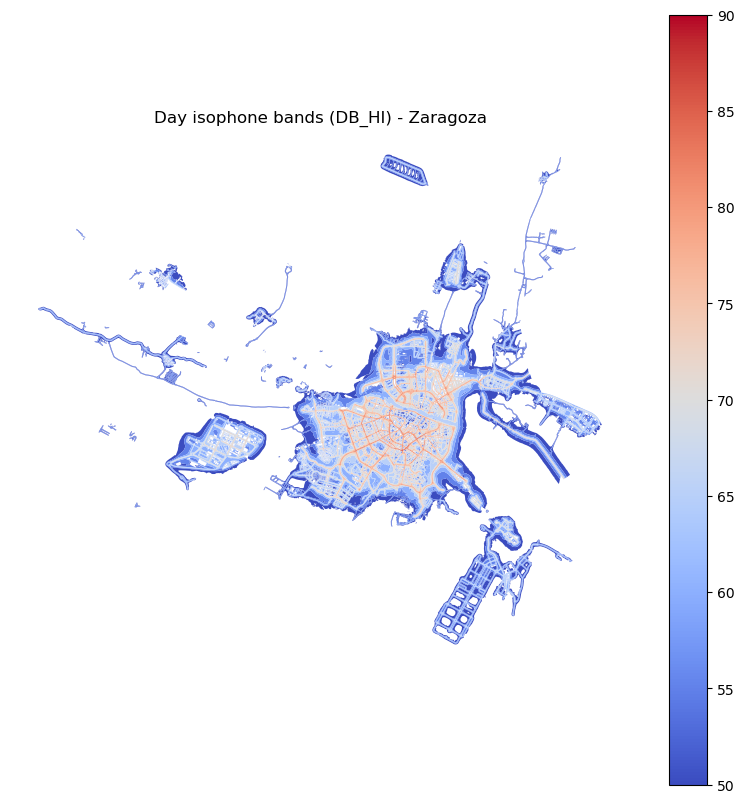

In [3]:
ax = iso_dia.plot(column='DB_HI', cmap='coolwarm', legend=True, figsize=(10, 10), linewidth=0)
ax.set_title('Day isophone bands (DB_HI) - Zaragoza')
ax.set_axis_off()

## Roads - OSM

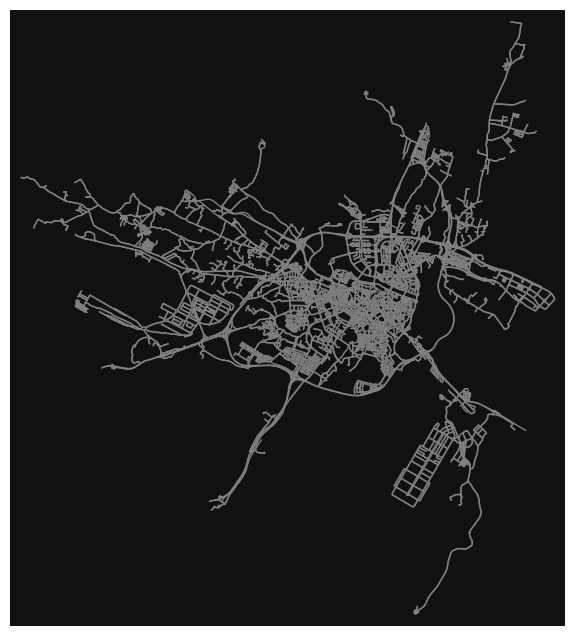

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
GRAPHML_PATH = os.path.join('data', 'zaragoza.graphml')
os.makedirs('data', exist_ok=True)

if os.path.exists(GRAPHML_PATH):
    print('Loading cached graph from', GRAPHML_PATH)
    G = ox.load_graphml(GRAPHML_PATH)
else:
    print('Downloading Zaragoza OSM graph (drive network) ...')
    G = ox.graph_from_place('Zaragoza, Spain', network_type='drive')
    ox.save_graphml(G, GRAPHML_PATH)

ox.plot_graph(G, edge_color='gray', node_size=0)

## Prepare graph edges (roads)

In [5]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to the same CRS as the isophones (EPSG:25830 — ETRS89 / UTM 30N)
roads = edges[edges.geometry.type == 'LineString'].to_crs(iso_dia.crs)
print('Roads:', len(roads), 'CRS:', roads.crs)

Roads: 17655 CRS: EPSG:25830


## Check features completeness

In [6]:
for col in ['width', 'maxspeed', 'lanes', 'oneway']:
    if col in roads.columns:
        print(f'Checking {col}..')
        print(roads[col].value_counts(dropna=False).head(20))
    else:
        print(f'{col}: column not present')

Checking width..
width
NaN               17598
6                    18
3                    10
3.5                   3
7.1                   3
6.7                   2
9.2                   2
5.5                   2
7                     2
19                    1
[8.2, 7.2]            1
3.3                   1
5.6                   1
4.8                   1
[5.7, 4.5, 12]        1
[2.8, 3.2]            1
3.6                   1
9                     1
3.8                   1
6.4                   1
Name: count, dtype: int64
Checking maxspeed..
maxspeed
NaN          7750
30           5874
50           3090
40            286
10            141
20            113
120            89
80             79
[50, 30]       51
[20, 30]       32
100            23
60             21
90             18
[10, 30]       16
[40, 50]       11
[80, 60]       10
[10, 20]        5
[80, 100]       5
[40, 60]        5
[120, 80]       3
Name: count, dtype: int64
Checking lanes..
lanes
NaN          5952
1            51

## Check if road is tunnel

In [7]:
# OSM 'tunnel' values can be strings or lists — mark as tunnel if any value is 'yes'
if 'tunnel' in roads.columns:
    roads['is_tunnel'] = roads['tunnel'].apply(
        lambda v: 1 if v == 'yes' or (isinstance(v, list) and 'yes' in v) else 0
    )
else:
    roads['is_tunnel'] = 0

print(roads['is_tunnel'].value_counts())

is_tunnel
0    17603
1       52
Name: count, dtype: int64


## Filter roads categories

In [8]:
# Filter to only primary and secondary roads
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)&
    (roads['is_tunnel'] == 0)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 17655, Filtered: 15712


## Plot road categories distribution

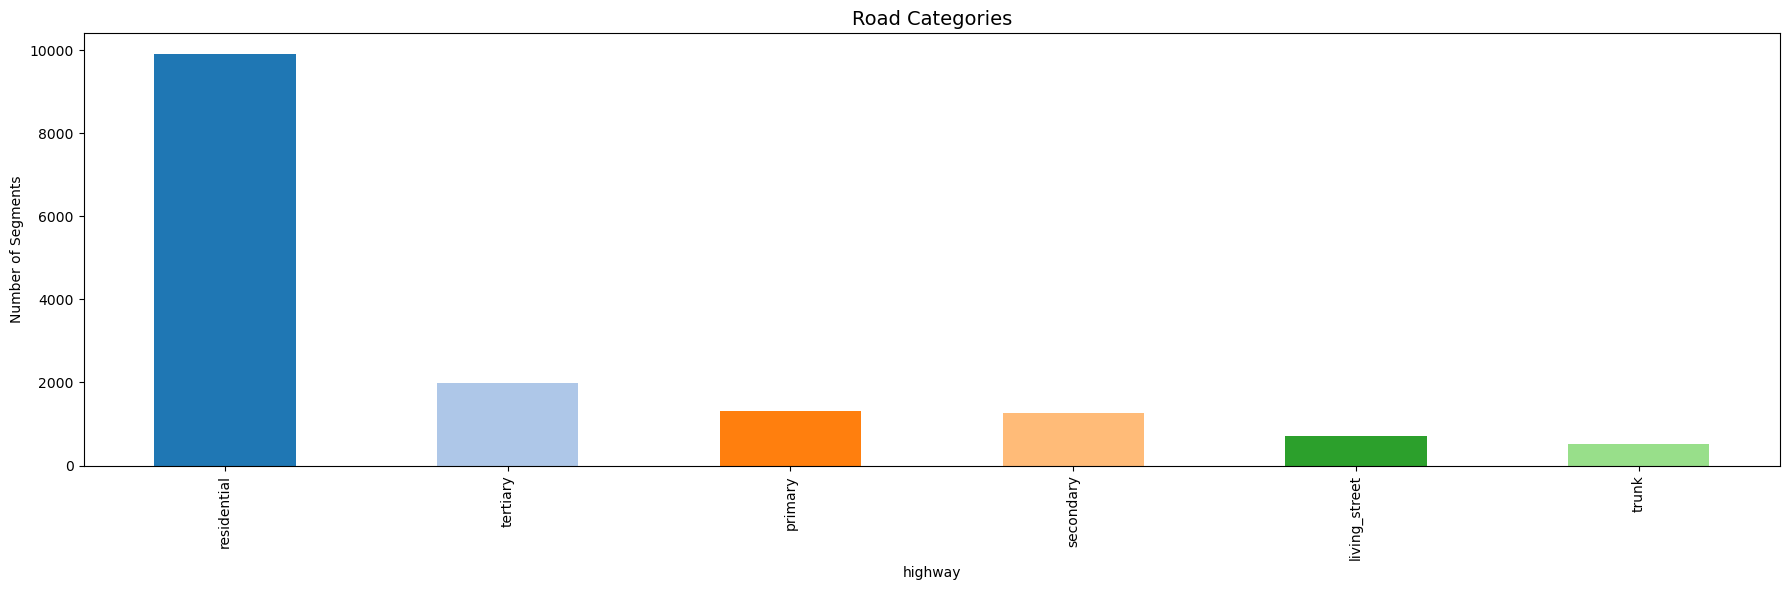

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

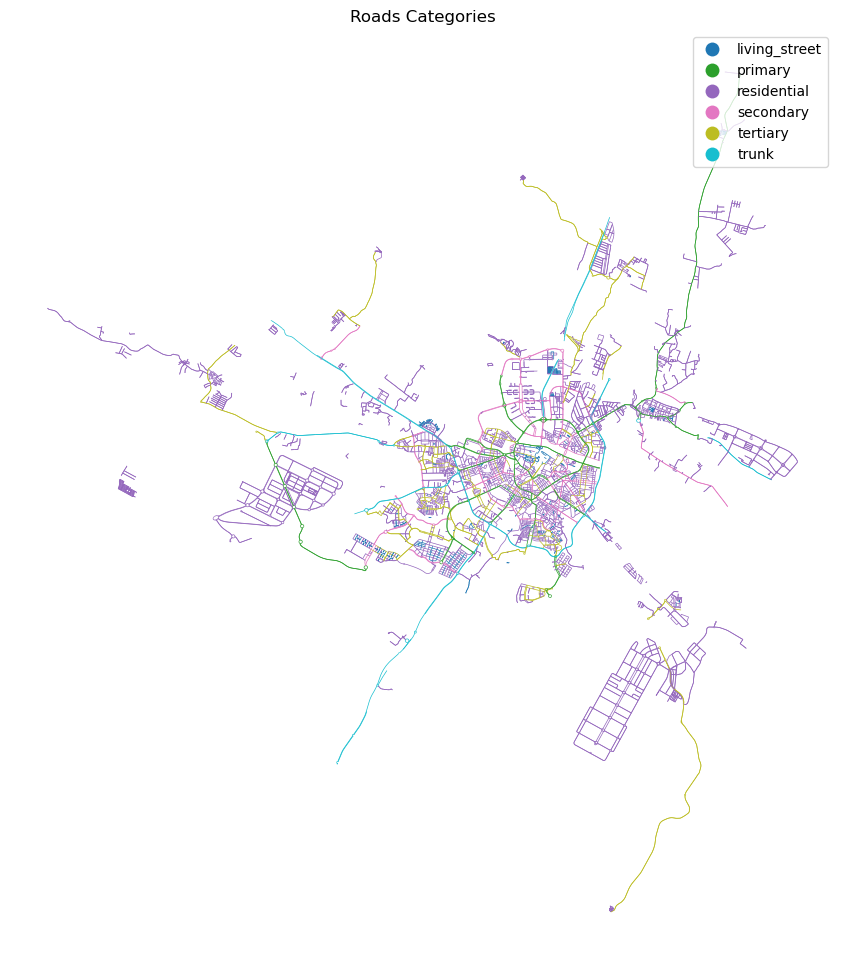

In [10]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Assign noise values to each street segment

Each OSM segment gets the dB value of the isophone band containing its midpoint, per period
(día 7–19h → `db_day`, tarde 19–23h → `db_evening`, noche 23–7h → `db_night`).

`DB_HI` is the **upper bound** of each 5-dB band (verified against the layer's SLD style:
`DB_HI = 60` is drawn with the standard 55–60 dB yellow); the band **lower bound**
(`DB_HI − 5`) is used, matching Barcelona's `extract_min` convention.

Midpoints with no día band (quiet streets below the lowest mapped band, or outside the urban
study area) are dropped and counted. Streets with a día band but no tarde/noche polygon are
quieter than the lowest band of that period: they get the lower bound of the period's lowest
band minus 5 dB (the analogue of Barcelona's `'< 40 dB(A)' → 35`).

In [11]:
# Midpoint -> point-in-polygon join against each period's isophone bands
noise_roads = roads_filtered.reset_index(drop=True).copy()
midpoints = noise_roads[['segment_id']].copy()
midpoints = gpd.GeoDataFrame(midpoints,
                             geometry=noise_roads.geometry.interpolate(0.5, normalized=True),
                             crs=noise_roads.crs)

iso_layers = {'db_day': iso_dia, 'db_evening': iso_tarde, 'db_night': iso_noche}
for col, iso in iso_layers.items():
    joined = gpd.sjoin(midpoints[['segment_id', 'geometry']], iso[['DB_HI', 'geometry']],
                       how='left', predicate='within')
    # A midpoint exactly on a band boundary can match twice - keep the first match
    joined = joined[~joined.index.duplicated(keep='first')]
    noise_roads[col] = joined['DB_HI'].astype(float) - 5  # band lower bound

noise_cols = ['db_day', 'db_evening', 'db_night']
n_total = len(noise_roads)
noise_roads = noise_roads[noise_roads['db_day'].notna()].copy()
print(f'Segments with a día band: {len(noise_roads)} / {n_total}')

# below the lowest mapped band of the period -> lowest lower bound minus 5 dB
for col, iso in iso_layers.items():
    fill_value = float(iso['DB_HI'].min()) - 10
    n_missing = int(noise_roads[col].isna().sum())
    if n_missing:
        noise_roads[col] = noise_roads[col].fillna(fill_value)
        print(f'{col}: {n_missing} segments below the lowest band, filled with {fill_value}')

noise_roads[noise_cols].describe()

Segments with a día band: 14600 / 15712
db_evening: 36 segments below the lowest band, filled with 40.0
db_night: 1622 segments below the lowest band, filled with 40.0


,db_day,db_evening,db_night
count,14600.000000,14600.000000,14600.000000
mean,64.107534,62.174315,53.301712
std,7.673250,7.417613,7.153010
min,45.000000,40.000000,40.000000
25%,60.000000,60.000000,50.000000
50%,65.000000,60.000000,55.000000
75%,70.000000,70.000000,60.000000
max,85.000000,80.000000,70.000000


## Classify noise into 5 classes: <40, 40-50, 50-60, 60-70, >70

In [12]:
# Classify numeric noise dB into 5 classes: 0=<40, 1=40-50, 2=50-60, 3=60-70, 4=>70

def classify_noise(val):
    if val < 40:
        return 0
    elif val < 50:
        return 1
    elif val < 60:
        return 2
    elif val < 70:
        return 3
    else:
        return 4

print(classify_noise(72.3))  # expected: 4

4


In [13]:
# Zaragoza's 2016 noise map provides all three periods directly:
# día (7-19h), tarde (19-23h) and noche (23-7h)
noise_roads['noise_day'] = noise_roads['db_day'].apply(classify_noise)
noise_roads['noise_evening'] = noise_roads['db_evening'].apply(classify_noise)
noise_roads['noise_night'] = noise_roads['db_night'].apply(classify_noise)

noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,junction,...,tunnel,access,segment_id,is_tunnel,db_day,db_evening,db_night,noise_day,noise_evening,noise_night
0,40602028,residential,1,30,Calle Bruno Solano,True,False,61.613974,"LINESTRING (675261.037 4611935.746, 675263.416...",NaN,...,NaN,NaN,30389382_249502424_0,0,65.0,65.0,55.0,3,3,2
1,295340402,primary,1,30,Paseo de Fernando el Católico,True,False,83.332676,"LINESTRING (675261.037 4611935.746, 675265.706...",NaN,...,NaN,NaN,30389382_30389461_0,0,75.0,70.0,60.0,4,4,3
2,"[688357635, 703200397]",secondary,2,50,Calle Violante de Hungría,True,False,191.771472,"LINESTRING (674719.448 4611869.784, 674750.94 ...",NaN,...,NaN,NaN,30389389_4398109455_0,0,75.0,70.0,60.0,4,4,3
3,4766203,primary,2,50,Paseo de Isabel la Católica,True,False,10.920622,"LINESTRING (675069.249 4611657.224, 675076.995...",NaN,...,NaN,NaN,30389391_30575132_0,0,75.0,75.0,65.0,4,4,3
4,"[1350876633, 53506724]",primary,2,50,Paseo de Echegaray y Caballero,True,False,75.276388,"LINESTRING (675512.603 4614046.799, 675520.573...",NaN,...,NaN,NaN,30389400_3847861549_0,0,75.0,70.0,65.0,4,4,3


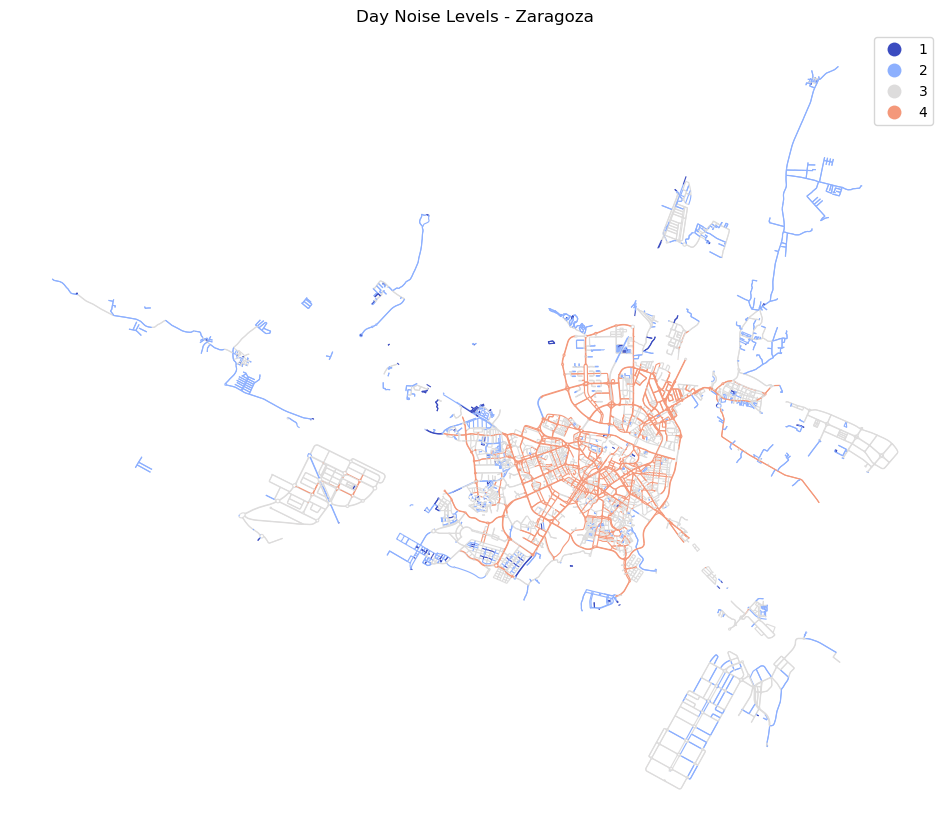

In [14]:
noise_roads['noise_day'] = noise_roads["noise_day"].astype("category")
ax = noise_roads.plot(cmap="coolwarm", column='noise_day', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Day Noise Levels - Zaragoza')
ax.set_axis_off()

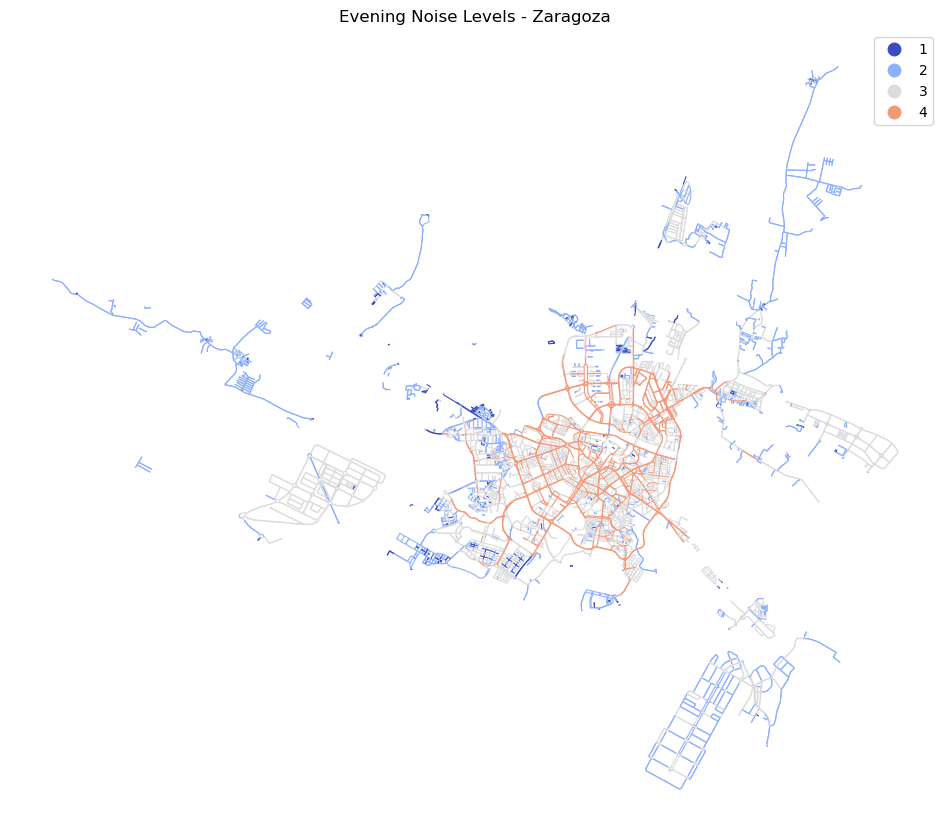

In [15]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Evening Noise Levels - Zaragoza')
ax.set_axis_off()

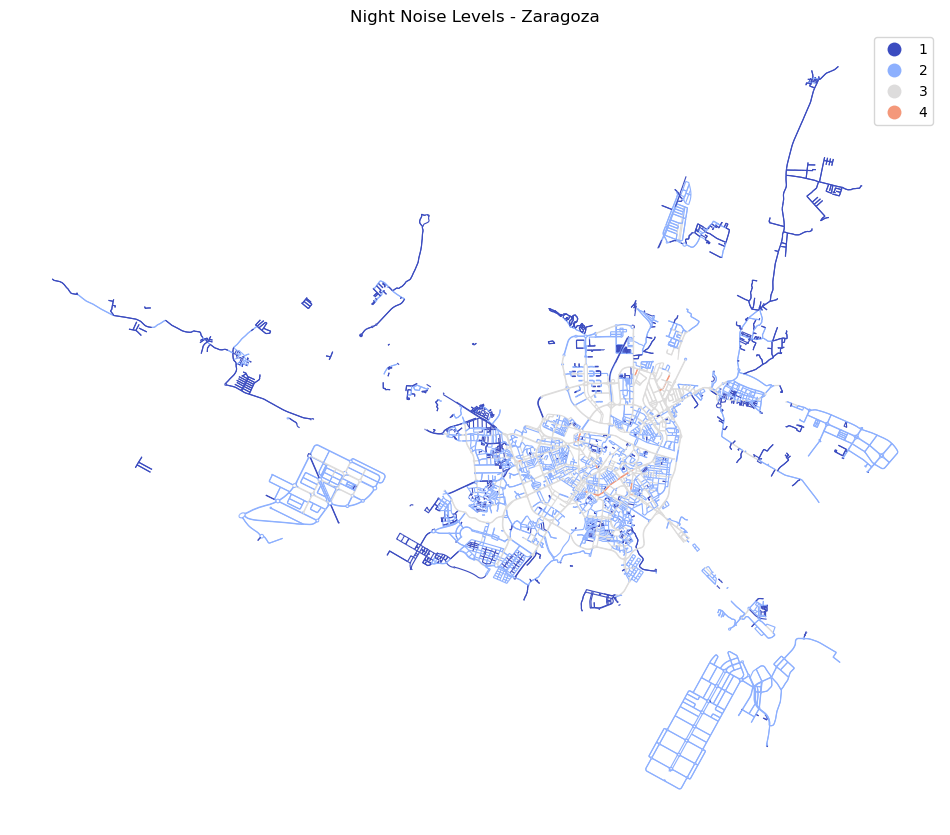

In [16]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Night Noise Levels - Zaragoza')
ax.set_axis_off()

## Convert category to numerical feature

In [17]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      9103
tertiary         1940
secondary        1275
primary          1263
living_street     651
trunk             368
Name: count, dtype: int64

In [18]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,junction,...,segment_id,is_tunnel,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,road_category,category_code
0,40602028,residential,1,30,Calle Bruno Solano,True,False,61.613974,"LINESTRING (675261.037 4611935.746, 675263.416...",NaN,...,30389382_249502424_0,0,65.0,65.0,55.0,3,3,2,residential,5
1,295340402,primary,1,30,Paseo de Fernando el Católico,True,False,83.332676,"LINESTRING (675261.037 4611935.746, 675265.706...",NaN,...,30389382_30389461_0,0,75.0,70.0,60.0,4,4,3,primary,2
2,"[688357635, 703200397]",secondary,2,50,Calle Violante de Hungría,True,False,191.771472,"LINESTRING (674719.448 4611869.784, 674750.94 ...",NaN,...,30389389_4398109455_0,0,75.0,70.0,60.0,4,4,3,secondary,3
3,4766203,primary,2,50,Paseo de Isabel la Católica,True,False,10.920622,"LINESTRING (675069.249 4611657.224, 675076.995...",NaN,...,30389391_30575132_0,0,75.0,75.0,65.0,4,4,3,primary,2
4,"[1350876633, 53506724]",primary,2,50,Paseo de Echegaray y Caballero,True,False,75.276388,"LINESTRING (675512.603 4614046.799, 675520.573...",NaN,...,30389400_3847861549_0,0,75.0,70.0,65.0,4,4,3,primary,2


## Calculate distance to the closest road of each category

In [19]:
# Ensure unique index and keep a stable row id for repeated nearest joins
noise_roads = noise_roads.reset_index(drop=True).copy()
noise_roads['road_idx'] = noise_roads.index

# Drop join helper columns if they exist to avoid conflicts in repeated runs
join_helper_cols = ['index_right'] + [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads = noise_roads.drop(columns=[col for col in join_helper_cols if col in noise_roads.columns], errors='ignore')

road_categories = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']

for category in road_categories:
    category_roads = noise_roads[noise_roads['highway'] == category][['geometry']].copy()
    distance_col = f'dist_to_{category}'

    if category_roads.empty:
        noise_roads[distance_col] = pd.NA
        continue

    nearest_category = noise_roads[['road_idx', 'geometry']].sjoin_nearest(
        category_roads,
        how='left',
        distance_col=distance_col
    )
    min_distances = nearest_category.groupby('road_idx')[distance_col].min()
    noise_roads[distance_col] = noise_roads['road_idx'].map(min_distances)

noise_roads = noise_roads.drop(columns=['road_idx']).drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,junction,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,40602028,residential,1,30,Calle Bruno Solano,True,False,61.613974,"LINESTRING (675261.037 4611935.746, 675263.416...",NaN,...,3,2,residential,5,1098.130859,0.000000,148.733726,294.245365,0.000000,80.489500
1,295340402,primary,1,30,Paseo de Fernando el Católico,True,False,83.332676,"LINESTRING (675261.037 4611935.746, 675265.706...",NaN,...,4,3,primary,2,1098.130859,0.000000,148.733726,328.711712,0.000000,0.000000
2,"[688357635, 703200397]",secondary,2,50,Calle Violante de Hungría,True,False,191.771472,"LINESTRING (674719.448 4611869.784, 674750.94 ...",NaN,...,4,3,secondary,3,733.149952,191.894385,0.000000,21.763470,0.000000,454.411270
3,4766203,primary,2,50,Paseo de Isabel la Católica,True,False,10.920622,"LINESTRING (675069.249 4611657.224, 675076.995...",NaN,...,4,3,primary,2,764.280886,0.000000,0.000000,403.268057,89.429710,407.502393
4,"[1350876633, 53506724]",primary,2,50,Paseo de Echegaray y Caballero,True,False,75.276388,"LINESTRING (675512.603 4614046.799, 675520.573...",NaN,...,4,3,primary,2,1318.929427,0.000000,66.397843,75.094780,28.661399,154.125944


In [20]:
# Summarize distance-to-category features
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads[distance_cols].describe()

,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
count,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000
mean,1313.673404,1117.090612,1291.124027,799.006653,17.971860,1095.178533
std,1497.001619,1520.267784,2001.712881,1325.342077,78.741075,1710.993297
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,366.567852,137.805994,106.457429,26.322798,0.000000,132.993478
50%,819.981795,452.163544,398.542296,238.054634,0.000000,367.978604
75%,1587.344639,1336.372680,1321.457396,892.096421,0.000000,1223.914546
max,8558.107121,9266.904426,10271.035675,7103.751499,1284.662747,13521.067109


## Calculate distance to major road

In [21]:
# Filter target roads
target_categories = ['trunk', 'primary', 'secondary' ]
target_roads = noise_roads[noise_roads['highway'].isin(target_categories)].copy()

# Ensure unique index
noise_roads = noise_roads.reset_index(drop=True)
target_roads = target_roads.reset_index(drop=True)

# Drop 'index_right' if it exists to avoid conflicts with sjoin_nearest
if 'index_right' in noise_roads.columns:
    noise_roads = noise_roads.drop(columns=['index_right'])

# Spatial join: each noise road gets its nearest target road (no duplication)
noise_roads = noise_roads.sjoin_nearest(
    target_roads[['geometry']], how='left', distance_col='dist_to_main'
)
noise_roads.fillna(0) #fillna(0) to replace any NaN values with 0
noise_roads = noise_roads.drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,junction,...,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,index_right,dist_to_main
0,40602028,residential,1,30,Calle Bruno Solano,True,False,61.613974,"LINESTRING (675261.037 4611935.746, 675263.416...",NaN,...,residential,5,1098.130859,0.000000,148.733726,294.245365,0.000000,80.489500,21,0.0
1,295340402,primary,1,30,Paseo de Fernando el Católico,True,False,83.332676,"LINESTRING (675261.037 4611935.746, 675265.706...",NaN,...,primary,2,1098.130859,0.000000,148.733726,328.711712,0.000000,0.000000,21,0.0
2,"[688357635, 703200397]",secondary,2,50,Calle Violante de Hungría,True,False,191.771472,"LINESTRING (674719.448 4611869.784, 674750.94 ...",NaN,...,secondary,3,733.149952,191.894385,0.000000,21.763470,0.000000,454.411270,2702,0.0
3,4766203,primary,2,50,Paseo de Isabel la Católica,True,False,10.920622,"LINESTRING (675069.249 4611657.224, 675076.995...",NaN,...,primary,2,764.280886,0.000000,0.000000,403.268057,89.429710,407.502393,152,0.0
4,"[1350876633, 53506724]",primary,2,50,Paseo de Echegaray y Caballero,True,False,75.276388,"LINESTRING (675512.603 4614046.799, 675520.573...",NaN,...,primary,2,1318.929427,0.000000,66.397843,75.094780,28.661399,154.125944,512,0.0


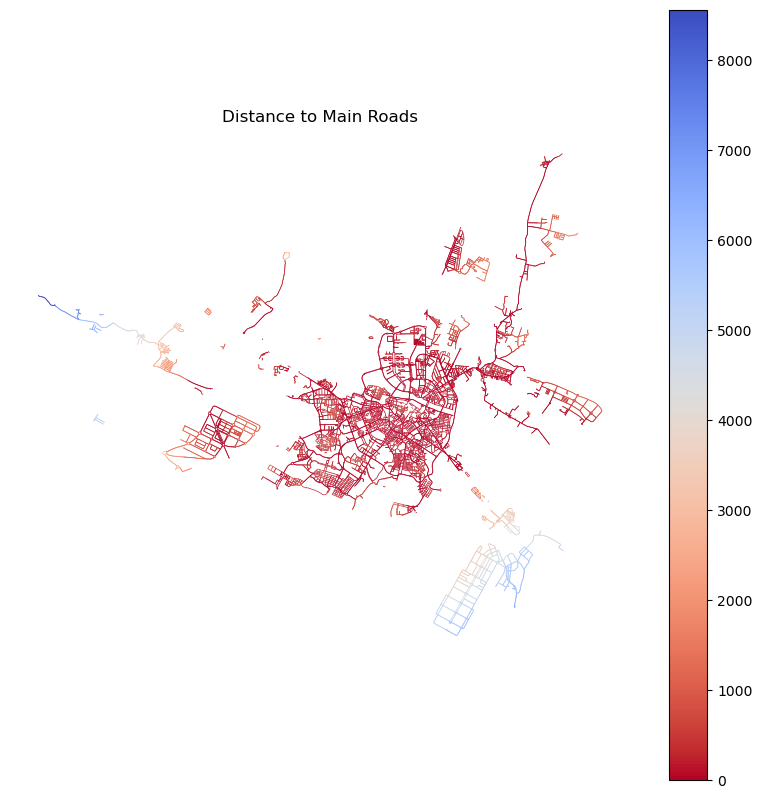

In [22]:
# Plot Distance to Main Roads
ax = noise_roads.plot(column='dist_to_main', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Distance to Main Roads')
ax.set_axis_off()

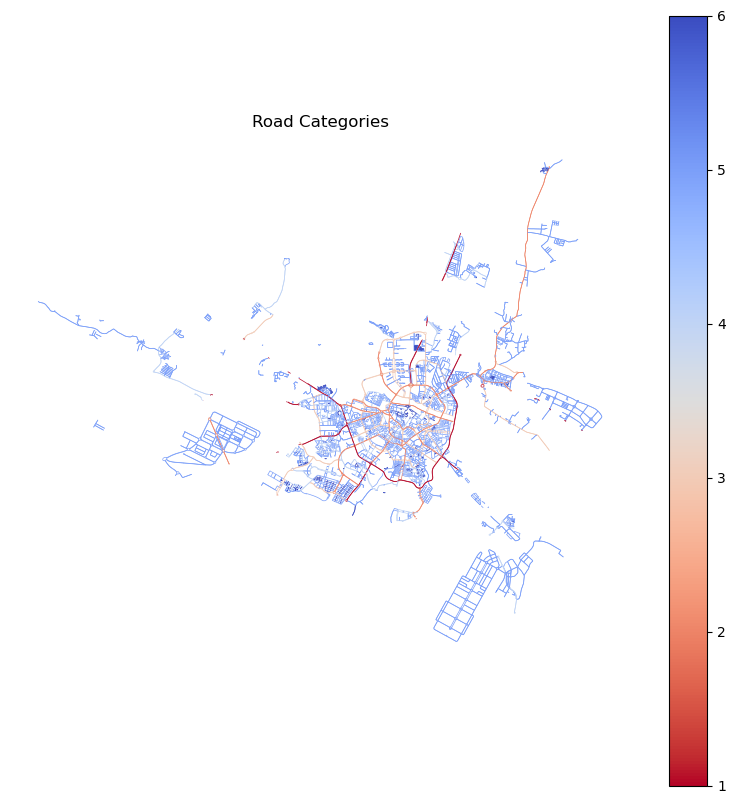

In [23]:
# Plot Road Categories
ax = noise_roads.plot(column='category_code', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [24]:
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,junction,...,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,index_right,dist_to_main
0,40602028,residential,1,30,Calle Bruno Solano,True,False,61.613974,"LINESTRING (675261.037 4611935.746, 675263.416...",NaN,...,residential,5,1098.130859,0.000000,148.733726,294.245365,0.000000,80.489500,21,0.0
1,295340402,primary,1,30,Paseo de Fernando el Católico,True,False,83.332676,"LINESTRING (675261.037 4611935.746, 675265.706...",NaN,...,primary,2,1098.130859,0.000000,148.733726,328.711712,0.000000,0.000000,21,0.0
2,"[688357635, 703200397]",secondary,2,50,Calle Violante de Hungría,True,False,191.771472,"LINESTRING (674719.448 4611869.784, 674750.94 ...",NaN,...,secondary,3,733.149952,191.894385,0.000000,21.763470,0.000000,454.411270,2702,0.0
3,4766203,primary,2,50,Paseo de Isabel la Católica,True,False,10.920622,"LINESTRING (675069.249 4611657.224, 675076.995...",NaN,...,primary,2,764.280886,0.000000,0.000000,403.268057,89.429710,407.502393,152,0.0
4,"[1350876633, 53506724]",primary,2,50,Paseo de Echegaray y Caballero,True,False,75.276388,"LINESTRING (675512.603 4614046.799, 675520.573...",NaN,...,primary,2,1318.929427,0.000000,66.397843,75.094780,28.661399,154.125944,512,0.0


## Export Zaragoza noise streets layer

ZGZ_noise_streets.gpkg (layer `noise_streets`) in `deployment/Zaragoza/layers/` — all filtered
street segments with segment_id, highway, name, length, dB values and noise classes. This is
the street layer consumed by the momepy / points / landuse notebooks.

In [25]:
export_cols = ['segment_id', 'highway', 'name', 'length',
               'db_day', 'db_evening', 'db_night',
               'noise_day', 'noise_evening', 'noise_night', 'geometry']
export_gdf = noise_roads[[c for c in export_cols if c in noise_roads.columns]].copy()
export_gdf['name'] = export_gdf['name'].astype(str)
export_gdf['noise_day'] = export_gdf['noise_day'].astype(int)

out_gpkg = os.path.join(_layers_dir, 'ZGZ_noise_streets.gpkg')
export_gdf.to_file(out_gpkg, layer='noise_streets', driver='GPKG')
print('Exported:', out_gpkg)
print('Segments:', len(export_gdf))

Exported: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Zaragoza\layers\ZGZ_noise_streets.gpkg
Segments: 14600


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


## Create data frame

In [26]:
dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'].astype(int),
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_category": noise_roads['category_code'],
    **{f'dist_to_{c}': noise_roads[f'dist_to_{c}'] for c in road_categories},
}).fillna(0)

dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,30389382_249502424_0,3,3,2,5,1098.130859,0.000000,148.733726,294.245365,0.000000,80.489500
1,30389382_30389461_0,4,4,3,2,1098.130859,0.000000,148.733726,328.711712,0.000000,0.000000
2,30389389_4398109455_0,4,4,3,3,733.149952,191.894385,0.000000,21.763470,0.000000,454.411270
3,30389391_30575132_0,4,4,3,2,764.280886,0.000000,0.000000,403.268057,89.429710,407.502393
4,30389400_3847861549_0,4,4,3,2,1318.929427,0.000000,66.397843,75.094780,28.661399,154.125944


## Check correlation with noise

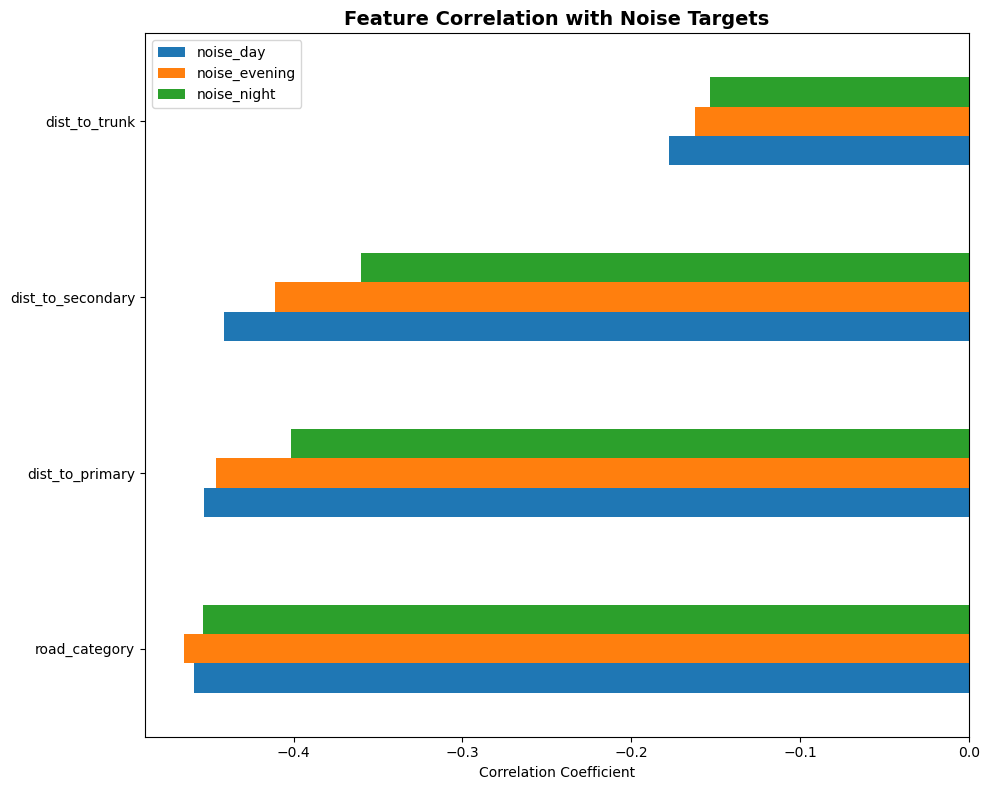

                   noise_day  noise_evening  noise_night
dist_to_trunk      -0.177804      -0.162319    -0.153563
dist_to_secondary  -0.441522      -0.410995    -0.360255
dist_to_primary    -0.453309      -0.445774    -0.401741
road_category      -0.458916      -0.464776    -0.453947


In [27]:
# Extract correlations with noise predictions
dataset_filtered = dataset[['noise_day', 'noise_evening', 'noise_night', 'road_category',
                            'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary']]
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Export dataset to CSV

In [28]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_noise_class.csv"), index=False)
print("Exported osm_roads_noise_class.csv")

Exported osm_roads_noise_class.csv
